In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib')
from variable_print import p,ps,pst

In [3]:
%%capture
!pip install --upgrade gymnasium[classic_control]

In [4]:
import gymnasium as gym
env = gym.make("CartPole-v1",render_mode="rgb_array")

# DDQN(Double DQN)

# Neural Network 적용

In [5]:
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Flatten, Lambda
from keras.optimizers import Adam
import keras.backend as K

from collections import deque
import numpy as np
import random
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore")

# Network

### Neural Network

In [6]:
learning_rate = 0.0005 # defalut : 0.001
hidden_units=256 #32 # 64

n_state = env.observation_space.shape[0]# 4
n_action = env.action_space.n           # 2

def Network():
    inp = keras.Input(shape=(n_state,))
    x = Dense(hidden_units, activation='relu')(inp)
    x = Dense(hidden_units, activation='relu')(x)
    x = Dense(n_action, activation='linear')(x)
    model = keras.models.Model(inp, x)
    model.compile(loss='mse', optimizer = Adam(learning_rate=learning_rate))
    return model

q_net = Network()
t_net = Network()
q_net.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,586 (264.01 KB)

 Trainable params: 67,586 (264.01 KB)

 Non-trainable params: 0 (0.00 B)

## Training

In [7]:
def get_batch():
    mini_batch = (random.sample(RM, batch_size))
    mini_batch_np = np.array(mini_batch, dtype=object)
    s = mini_batch_np[:,0]    # (bs,array):  [array([]) array([])]
    s = np.stack(s)           # s(bs,4)    : [[][]]
    a = mini_batch_np[:,1]    # a(bs,)
    r = mini_batch_np[:,2]    # r(bs,)
    ns = mini_batch_np[:,3]   #
    ns = np.stack(ns)         # s'(bs,4)
    done = mini_batch_np[:,4] # T(bs,)
    return s,a,r,ns,done

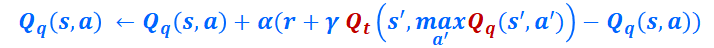

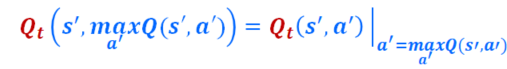

In [8]:
def model_learning(epochs):
    s,a,r,ns,done = get_batch()          # batch <- random(RM,batch_size)
    target = q_net.predict(s,verbose=0)  # target:(bs,a)<-q(s):(bs,s)
    next_q = q_net.predict(ns,verbose=0) # nq:(bs,a)<-q(s')
    q_targ = t_net.predict(ns,verbose=0) # qt:(bs,a)<-q_t(s')

    for i in range(batch_size):
        if done[i]:                # done
            target[i][a[i]] = r[i] # target(s,a) = r
        else:                      # target(s,a) = r + gamma*q_t(s',max_a(q(s'))
            max_na_idx = np.argmax(next_q[i,:]) # a'=max_a(q(s'))
            target[i][a[i]] = r[i]+gamma*q_targ[i,max_na_idx]# <-r+gamma*q_t(s',a')
    # Train on batch
    history = q_net.fit(s, target, batch_size=batch_size2, epochs=epochs, verbose=0)
    return history.history['loss'][0]

In [9]:
@tf.function
def update_t_network(tau):
    W = q_net.variables
    tgt_W = t_net.variables
    for (a, b) in zip(tgt_W, W):
        a.assign(b * tau + a * (1 - tau))

### epsilon-greedy scheduling

In [10]:
def eps_schedule(step=0, plot= False):
    eps_decay_step =  n_episode // down_steps
    epsilon = max(0.01, eps_start*eps_decay**(step//eps_decay_step))
    if plot == True :
        epsilon_l=[]
        for i in range(n_episode):
            n_eps = max(0.01, eps_start*eps_decay**(i//eps_decay_step))
            epsilon_l.append(n_eps)
        plt.plot(epsilon_l)
        plt.grid()
        plt.show()
    return epsilon

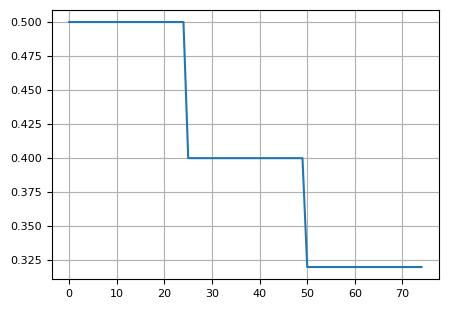

In [11]:
n_episode = 75

eps_start = 0.5   # epsilon 초기값
epsilon = eps_start
eps_decay = 0.8
down_steps = 3
epsilon = eps_schedule(plot=True)

In [12]:
def get_action(state,epsilon): #epsilon greedy policy
    r_eps = np.random.random()
    epsilon = eps_schedule(i)
    if(r_eps < epsilon): # exploration: eps-greedy
        a = np.random.randint(0, n_action)
    else:                # exploitation
        ## Q-Network에서 q값 추정
        q = q_net.predict(np.reshape(state,[1,4]), verbose=0)
        a = np.argmax(q[0])     # greedy
    return a, epsilon

## Training Loop

In [15]:
%%time
n_episode = 10 # 75   ####
batch_size = 32 # 128 ####

batch_size2 = batch_size
epochs = 1
tau = 0.3
gamma = 0.95
buffer_size = 2000
RM=deque(maxlen=buffer_size)

tf.keras.utils.set_random_seed(7)
env.reset()

q_net = Network()
t_net = Network()
update_t_network(tau=1) # T-Net <- Q-Net

scores=[0]       # Eps.별 누적보상
mean_scores = []
max_steps=170    # Eps.최대 step

# RL Training loop
for i in range(n_episode):
    s, _ = env.reset()                 # s <- random
    score = loss = 0                # Eps.별 보상
    while True :                    # Termination 까지
        a, epsilon = get_action(s, epsilon)# epsilon greedy policy
        ns, r, done, _, _ = env.step(a)# step(a)
        if done and score < max_steps: r -= 100 # 중간에 끝나면 벌점
        RM.append([s,a,r,ns,done])
        ## Q-Network Training
        if len(RM) > batch_size * 1: ##3
            loss = model_learning(5)  # step마다 Q-Net Training
            update_t_network(tau)   # T-Net <- Q-Net
        s = ns
        score += r                   # episode내 reward
        if done : break
#        if score > max_steps * 1.5 : break
#    update_t_network(tau=1.0)        # T-Net <- Q-Net
    score = score if score > max_steps  else score + 100 # 벌점 보상
    mean_score = np.mean(scores[-10:])
    mean_scores.append(mean_score)
    max_steps = mean_score * 1.5 ###
    print(f'Eps.[{i:03d}], score:{score}, Mean score:{int(mean_score):.2f},\
 loss:{loss:.2f}, Epsilon:{epsilon:.2f}, Length_RM:{len(RM)}')
    scores.append(score)
    if mean_score > max_steps : break
env.close()

Eps.[000], score:10.0, Mean score:0.00, loss:0.00, Epsilon:0.50, Length_RM:10
Eps.[001], score:13.0, Mean score:5.00, loss:0.00, Epsilon:0.50, Length_RM:23
Eps.[002], score:14.0, Mean score:7.00, loss:146.74, Epsilon:0.50, Length_RM:37
Eps.[003], score:13.0, Mean score:9.00, loss:126.04, Epsilon:0.40, Length_RM:50
Eps.[004], score:11.0, Mean score:10.00, loss:301.93, Epsilon:0.40, Length_RM:61
Eps.[005], score:28.0, Mean score:10.00, loss:126.70, Epsilon:0.40, Length_RM:89
Eps.[006], score:53.0, Mean score:12.00, loss:6.21, Epsilon:0.32, Length_RM:142
Eps.[007], score:26.0, Mean score:17.00, loss:124.12, Epsilon:0.32, Length_RM:168
Eps.[008], score:20.0, Mean score:18.00, loss:1.46, Epsilon:0.32, Length_RM:188
Eps.[009], score:48.0, Mean score:18.00, loss:8.98, Epsilon:0.26, Length_RM:236
CPU times: user 1min 32s, sys: 6.58 s, total: 1min 39s
Wall time: 1min 35s


In [ ]:
%%time
n_episode = 75   ####
batch_size = 128 ####
batch_size2 = batch_size
epochs = 1
tau = 0.01#0.1 #0.8, 0.5

gamma = 0.95
buffer_size = 20000
RM=deque(maxlen=buffer_size)

tf.keras.utils.set_random_seed(7)
env.reset()

q_net = Network()
t_net = Network()
update_t_network(tau=1) # T-Net <- Q-Net

scores=[0]       # Eps.별 누적보상
mean_scores = []
max_steps=170    # Eps.최대 step

# RL Training loop
for i in range(n_episode):
    s, _ = env.reset()                 # s <- random
    score = loss = 0                # Eps.별 보상
    while True :                    # Termination 까지
        a, epsilon = get_action(s, epsilon)# epsilon greedy policy
        ns, r, done, _, _ = env.step(a)# step(a)
        if done and score < max_steps: r -= 100 # 중간에 끝나면 벌점
        RM.append([s,a,r,ns,done])
        ## Q-Network Training
        if len(RM) > batch_size * 1: ##3
            loss = model_learning(5)  # step마다 Q-Net Training
            update_t_network(tau)   # T-Net <- Q-Net
        s = ns
        score += r                   # episode내 reward
        if done : break
#        if score > max_steps * 1.5 : break
#    update_t_network(tau=1.0)        # T-Net <- Q-Net
    score = score if score > max_steps  else score + 100 # 벌점 보상
    mean_score = np.mean(scores[-10:])
    mean_scores.append(mean_score)
    max_steps = mean_score * 1.5 ###
    print(f'Eps.[{i:03d}], score:{score}, Mean score:{int(mean_score):.2f},\
 loss:{loss:.2f}, Epsilon:{epsilon:.2f}, Length_RM:{len(RM)}')
    scores.append(score)
    if mean_score > max_steps : break
env.close()
# Wall time: 8min 52s

Eps.[000], score:9.0, Mean score:0.00, loss:0.00, Epsilon:0.50, Length_RM:9
Eps.[001], score:11.0, Mean score:4.00, loss:0.00, Epsilon:0.50, Length_RM:20
Eps.[002], score:12.0, Mean score:6.00, loss:0.00, Epsilon:0.50, Length_RM:32
Eps.[003], score:10.0, Mean score:8.00, loss:0.00, Epsilon:0.50, Length_RM:42
Eps.[004], score:9.0, Mean score:8.00, loss:0.00, Epsilon:0.50, Length_RM:51
Eps.[005], score:10.0, Mean score:8.00, loss:0.00, Epsilon:0.50, Length_RM:61
Eps.[006], score:12.0, Mean score:8.00, loss:0.00, Epsilon:0.50, Length_RM:73
Eps.[007], score:15.0, Mean score:9.00, loss:0.00, Epsilon:0.50, Length_RM:88
Eps.[008], score:15.0, Mean score:9.00, loss:0.00, Epsilon:0.50, Length_RM:103
Eps.[009], score:9.0, Mean score:10.00, loss:0.00, Epsilon:0.50, Length_RM:112
Eps.[010], score:11.0, Mean score:11.00, loss:0.00, Epsilon:0.50, Length_RM:123
Eps.[011], score:11.0, Mean score:11.00, loss:293.39, Epsilon:0.50, Length_RM:134
Eps.[012], score:22.0, Mean score:11.00, loss:244.84, Epsil

# Evaluation  

In [ ]:
condition = f'hidden_units:{hidden_units}, eps_start:{eps_start}, '+\
            f'eps_start:{eps_start}, eps_decay:{eps_decay}, tau:{tau}'

plt.plot(scores)
plt.plot(mean_scores)
plt.title(f"DDQN scores for CartPole\n {condition}")
plt.ylabel('Score')
plt.xlabel('Episode')
plt.grid()
plt.show()

hidden_units:256, eps_start:0.5
eps_start:0.5,eps_decay:0.8,tau:0.1  
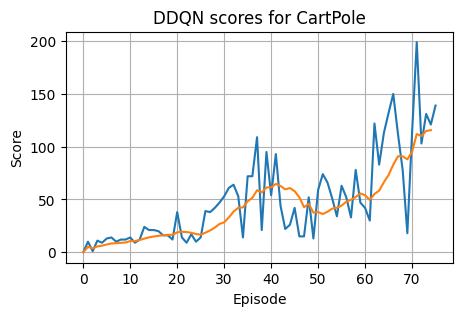

hidden_units:256, eps_start:0.5
eps_start:0.5,eps_decay:0.8,tau:0.01  
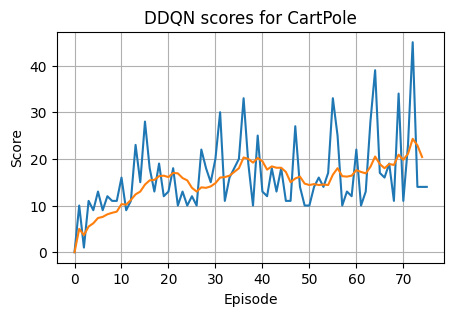

hidden_units:256, eps_start:0.8
eps_start:0.8,eps_decay:0.6,tau:0.01  
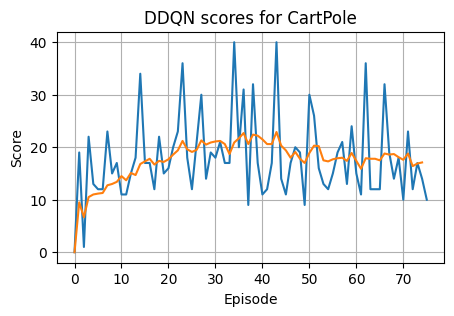

hidden_units:256, eps_start:0.5
eps_start:0.5,eps_decay:0.8,tau:0.01  
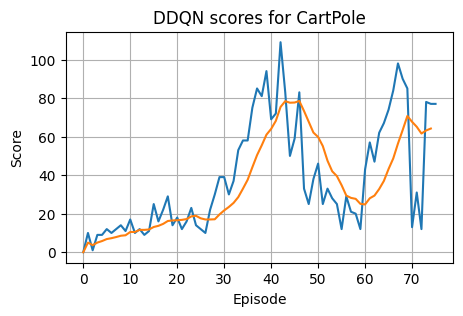

  if score > max_steps * 1.5 : break    
  hidden_units:256, eps_start:0.5  
eps_start:0.5,eps_decay:0.8, tau:0.1    
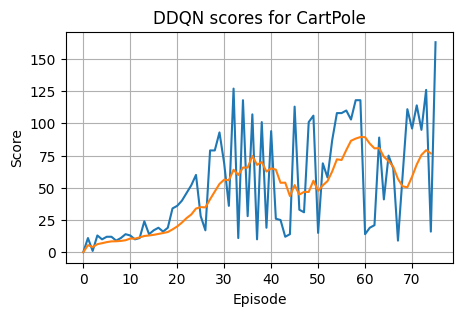

hidden_units:256, eps_start:0.5  
eps_start:0.5,eps_decay:0.8  

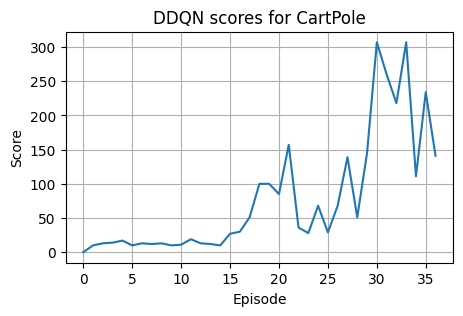

hidden_units=256  
eps_start = 0.5    
eps_decay = 0.8  
tau = 0.8 : epi 내부   


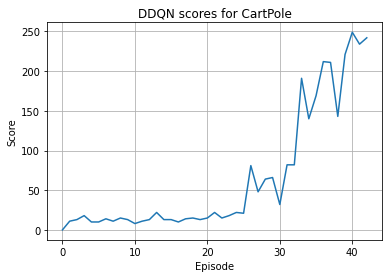  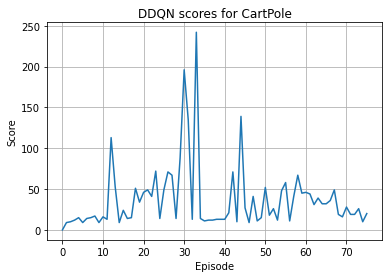

eps_decay = 1.0 epi 외부  
hidden_units = 32  <- 250  


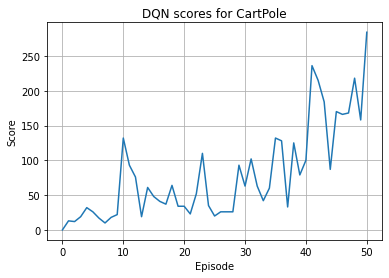

hidden_units =  250  
eps_decay = 0.8 epi내부



tau = 0.3


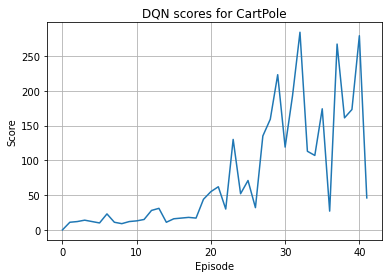

tau = 0.8  


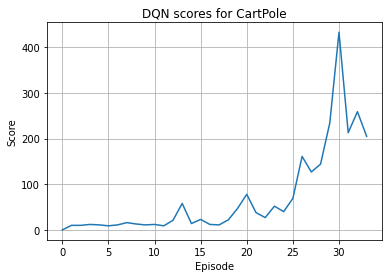

In [ ]:
#q_net.save(path+'/models/DRL/DDQN.h5')
#q_net = keras.models.load_model(path+"/models/DRL/DDQN.h5")

In [ ]:
%%time
%%capture
!pip install gym pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [ ]:
from render import  show_video, wrap_env, render_as_image

In [ ]:
from pyvirtualdisplay import Display
display = Display(visible=0, size=(400, 300))
display.start()

In [ ]:
env = wrap_env(env, path=path, name_prefix="DDQN-cartpole")

In [ ]:
state = env.reset()
cnt = 0
while True:
    render_as_image(env,step=cnt)
    predict = q_net.predict(state.reshape(1,4),verbose=0)
    action = np.argmax(predict)
    state, reward, done, info = env.step(action)
    if done:  break;
    cnt += 1
env.close()

In [ ]:
show_video(path=path,name_prefix='DDQN-cartpole')